The report uses seaborn, matplotlib, folim, and plotly. 
1. Seaborn
What it Does: Seaborn is a data visualization library based on Matplotlib that provides a high-level interface for drawing attractive and informative statistical graphics. It simplifies the process of creating complex visualizations such as heatmaps, violin plots, and categorical plots, and it comes with several built-in themes and color palettes to make the plots look more appealing.
Origin: Seaborn was created by Michael Waskom and is tightly integrated with the Pandas data manipulation library. It is built on top of Matplotlib and was designed to work seamlessly with data frames in Pandas.
2. Matplotlib
What it Does: Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is the foundational plotting library in Python, providing functionalities to create a wide range of plots and charts including line plots, scatter plots, bar charts, and histograms.
Origin: Matplotlib was created by John D. Hunter in 2003. It was initially developed as a way to generate plots for scientific papers and has since grown to be one of the most widely used visualization libraries in the Python ecosystem.
3. Folium
What it Does: Folium is a library used for visualizing geospatial data. It makes it easy to create interactive maps with Leaflet.js, a leading JavaScript library for interactive maps. With Folium, you can create maps with various tiles, add markers, pop-ups, and geojson overlays to visualize spatial data.
Origin: Folium was created by the Python community to leverage the Leaflet.js library in Python. It is commonly used in geospatial analysis and GIS (Geographic Information Systems) applications.
4. Plotly
What it Does: Plotly is a graphing library that makes interactive, publication-quality graphs online. It can create a variety of visualizations, including scatter plots, line charts, bar charts, and 3D plots. One of its key features is interactivity, which allows users to zoom, pan, and hover over data points to get more information.
Origin: Plotly was developed by Plotly Inc., a company founded in 2012 by Alex Johnson, Chris Parmer, and Jack Parmer. It has both open-source and commercial versions, and it integrates well with Jupyter notebooks, web applications, and dashboards.

In [32]:
import sys
!"{sys.executable}" -m pip install -U mlxtend

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------------- - 1.3/1.4 MB 22.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- -------------------------

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
import folium 
from folium.plugins import HeatMap
import requests
from io import StringIO
from matplotlib.patches import Patch
from plotly.subplots import make_subplots
from pathlib import Path
import os
from dotenv import load_dotenv


mlxtend library includes tools for data science and machine learning tasks, such as the Apriori algorithm used for association rule learning.

Patch from matplotlib.patches is used for creating graphical objects in plots. These objects can include rectangles, circles, polygons, and custom shapes, which can be added to matplotlib plots for various purposes. Patches are often used to create legends, highlight specific areas of a plot, or add custom shapes and annotations. For example, in a bar plot, different colored patches can represent different categories in the legend, making the plot more informative and easier to understand.

In [2]:
%pwd

'c:\\Users\\rasman khurshid\\Visualization\\notebooks'

# Section 1: Dataset Loading and Preprocessing

In [3]:

# Load environment variables from .env (if present)
load_dotenv()

# Find project root reliably (works whether you run from repo root or /notebooks)
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd

# Option A: user provides full file path in .env as DATA_PATH
DATA_PATH = os.getenv("DATA_PATH")

# Option B (default): file is placed inside repo's /data folder
DEFAULT_PATH = PROJECT_ROOT / "data" / "Crime_Data_from_2020_to_Present.csv"

csv_path = Path(DATA_PATH) if DATA_PATH else DEFAULT_PATH

if not csv_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {csv_path}\n\n"
        f"Fix options:\n"
        f"1) Put the CSV here: {DEFAULT_PATH}\n"
        f"OR\n"
        f"2) Create a .env file in the repo root and set:\n"
        f"   DATA_PATH=C:\\path\\to\\Crime_Data_from_2020_to_Present.csv"
    )

df = pd.read_csv(csv_path)
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,BATTERY - SIMPLE ASSAULT,...,AO,Adult Other,624.0,NaN,NaN,NaN,1100 W 39TH PL,NaN,34.0141,-118.2978
1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,700 S HILL ST,NaN,34.0459,-118.2545
2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,AA,Adult Arrest,845.0,NaN,NaN,NaN,200 E 6TH ST,NaN,34.0448,-118.2474
3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,IC,Invest Cont,745.0,998.0,NaN,NaN,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,14400 TITUS ST,NaN,34.2198,-118.4468


## 1.1 Data Cleaning 

In [4]:

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)


Missing Values:
 DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           122296
Vict Age               0
Vict Sex          116302
Vict Descent      116310
Premis Cd             10
Premis Desc          535
Weapon Used Cd    574020
Weapon Desc       574020
Status                 0
Status Desc            0
Crm Cd 1              11
Crm Cd 2          814910
Crm Cd 3          876939
Crm Cd 4          879044
LOCATION               0
Cross Street      740005
LAT                    0
LON                    0
dtype: int64


In [5]:
# Handling missing values

# Check for any data inconsistencies
print(df['Vict Age'].unique())  # Check age distribution
print(df['Vict Sex'].unique())  # Check sex categories

# Remove rows where 'Vict Age' is negative
df = df[df['Vict Age'] >= 0]

# Display the unique values in 'Vict Age' after filtering to confirm
print("Unique ages after filtering:", df['Vict Age'].unique())

# Check the distribution of 'Vict Sex' before making changes
print("Gender distribution before:", df['Vict Sex'].value_counts())

# Normalize the 'Vict Sex' column by replacing erroneous values
df['Vict Sex'] = df['Vict Sex'].replace({'H': 'X', '-': 'X'})
# Remove rows where 'Vict Sex' is 'X' if considering it as missing data
#df = df[df['Vict Sex'] != 'X']

# Check the final gender distribution
print("Final Gender distribution:", df['Vict Sex'].value_counts())


# Check the distribution of 'Vict Sex' after making changes
print("Gender distribution after:", df['Vict Sex'].value_counts())

# Mapping Premis Codes to Descriptions
premis_mapping = (
    df.dropna(subset=['Premis Cd', 'Premis Desc'])
      .drop_duplicates(subset=['Premis Cd'])
      .set_index('Premis Cd')['Premis Desc']
      .to_dict()
)

df['Premis Desc'] = df['Premis Cd'].map(premis_mapping).fillna(df['Premis Desc'])

# For columns where 'No applicable data' might be filled
# Keep codes numeric; use a numeric sentinel for "missing"
df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0).astype('int64')   # 0 = No weapon / missing code
df['Weapon Desc'] = df['Weapon Desc'].fillna('No Weapon')

# For additional crime codes
for col in ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']:
    df[col] = df[col].fillna(0).astype('int64')   # 0 = no additional crime code

# For Cross Street
df['Cross Street'].fillna('Not Applicable', inplace=True)



[ 36  25   0  76  31  23  29  35  41  24  66  27  62  71  19  51  69  52
  38  55  34  40  44  57  18  54  22  28  43  46  56  67  37  60  61  59
  32  30  50  45  20  58  48  26  47  21  64  39  75  12  68  13  33  53
  74  49  65  16  14  72  81  63  15  90  85  79  94  42  73  17  78  11
  82  80   5  77  84  88  96  99  86   7  70  92   3  83  10   6   9  87
   8  89  91   2   4  97  95  93  98 120  -2  -1  -3]
<StringArray>
['F', 'M', 'X', nan, 'H', '-']
Length: 6, dtype: str
Unique ages after filtering: [ 36  25   0  76  31  23  29  35  41  24  66  27  62  71  19  51  69  52
  38  55  34  40  44  57  18  54  22  28  43  46  56  67  37  60  61  59
  32  30  50  45  20  58  48  26  47  21  64  39  75  12  68  13  33  53
  74  49  65  16  14  72  81  63  15  90  85  79  94  42  73  17  78  11
  82  80   5  77  84  88  96  99  86   7  70  92   3  83  10   6   9  87
   8  89  91   2   4  97  95  93  98 120]
Gender distribution before: Vict Sex
M    361357
F    322360
X     78913
H    

C:\Users\rasman khurshid\AppData\Local\Temp\ipykernel_13640\2654652349.py:48: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Cross Street'].fillna('Not Applicable', inplace=True)


0                          Not Applicable
1                          Not Applicable
2                          Not Applicable
3                          Not Applicable
4                          Not Applicable
                       ...               
879101                     Not Applicable
879102                         LONG BEACH
879103                     Not Applicable
879104    DE GARMO                     AV
879105                     Not Applicable
Name: Cross Street, Length: 879027, dtype: str

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           122293
Vict Age               0
Vict Sex          116302
Vict Descent      116310
Premis Cd             10
Premis Desc          535
Weapon Used Cd         0
Weapon Desc            0
Status                 0
Status Desc            0
Crm Cd 1              11
Crm Cd 2               0
Crm Cd 3               0
Crm Cd 4               0
LOCATION               0
Cross Street      739929
LAT                    0
LON                    0
dtype: int64


In [7]:
# Check records with missing 'Premis Cd'
missing_premis_records = df[df['Premis Cd'].isna()]
print(missing_premis_records[['LOCATION', 'Crm Cd Desc', 'Premis Desc']])

# Check records with missing 'Crm Cd 1'
missing_crm_cd_1_records = df[df['Crm Cd 1'].isna()]
print(missing_crm_cd_1_records[['Crm Cd Desc', 'Crm Cd']])


                                        LOCATION  \
56363            SUNSET                       BL   
140502   9400    VAN NUYS                     BL   
341562   3900    VAN HORNE                    AV   
380368   1200    WESTCHESTER                  PL   
386525   3200    OVERLAND                     AV   
502400   9800    LAUREL CANYON                BL   
507641    400 E  68TH                         ST   
539898  14900 S  MENLO                        AV   
645675   2200 N  FIGUEROA                     ST   
669492  18300    ROSCOE                       BL   

                                            Crm Cd Desc Premis Desc  
56363                                  VEHICLE - STOLEN         NaN  
140502                                 VEHICLE - STOLEN         NaN  
341562  THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)         NaN  
380368  THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)         NaN  
386525                        OTHER MISCELLANEOUS CRIME         NaN  
502400 

In [8]:
# Drop rows where any of these important columns are missing
df = df.dropna(subset=['Premis Cd', 'Premis Desc', 'Crm Cd 1'])

# Verify no more missing values in those columns
print(df[['Premis Cd', 'Premis Desc', 'Crm Cd 1']].isna().sum())

Premis Cd      0
Premis Desc    0
Crm Cd 1       0
dtype: int64


In [9]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           122281
Vict Age               0
Vict Sex          116291
Vict Descent      116299
Premis Cd              0
Premis Desc            0
Weapon Used Cd         0
Weapon Desc            0
Status                 0
Status Desc            0
Crm Cd 1               0
Crm Cd 2               0
Crm Cd 3               0
Crm Cd 4               0
LOCATION               0
Cross Street      739405
LAT                    0
LON                    0
dtype: int64


In [10]:
# Check for duplicate entries
duplicate_entries = df.duplicated().sum()
print("Duplicate Entries:", duplicate_entries)

Duplicate Entries: 0


In [11]:
# Check data types of each column
print(df.dtypes)

DR_NO               int64
Date Rptd             str
DATE OCC              str
TIME OCC            int64
AREA                int64
AREA NAME             str
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc           str
Mocodes               str
Vict Age            int64
Vict Sex              str
Vict Descent          str
Premis Cd         float64
Premis Desc           str
Weapon Used Cd      int64
Weapon Desc           str
Status                str
Status Desc           str
Crm Cd 1          float64
Crm Cd 2            int64
Crm Cd 3            int64
Crm Cd 4            int64
LOCATION              str
Cross Street          str
LAT               float64
LON               float64
dtype: object


## 1.2 Date and Time Data Type Conversion 

In [29]:
# Function to safely convert a column to datetime
def safe_convert_to_datetime(df, column_name, date_format):
    if not pd.api.types.is_datetime64_any_dtype(df[column_name]):
        df[column_name] = pd.to_datetime(df[column_name], format=date_format, errors='coerce')
    else:
        print(f"The column '{column_name}' is already in datetime format.")

# Convert 'Date Rptd' and 'DATE OCC' to datetime
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
# Always normalize column names once
df.columns = df.columns.str.strip()

# For any time-series analysis, DATE OCC must exist
df = df.dropna(subset=["DATE OCC"])

# Create Year/Month once (use DATE OCC as the source)
df["Year"] = df["DATE OCC"].dt.year
df["Month"] = df["DATE OCC"].dt.month
# Check the first few rows to confirm the conversion
print(df[['DATE OCC']].head())

# Check for any remaining missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Convert 'Date Rptd' to datetime format
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Check the first few rows to confirm the conversion
print(df[['Date Rptd']].head())

# Check for any remaining missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Check the data types
print(df.dtypes)

    DATE OCC
0 2020-01-08
1 2020-01-01
2 2020-02-13
3 2020-01-01
4 2020-01-01
Missing Values:
 DR_NO                     0
Date Rptd                 0
DATE OCC                  0
TIME OCC                  0
AREA                      0
AREA NAME                 0
Rpt Dist No               0
Part 1-2                  0
Crm Cd                    0
Crm Cd Desc               0
Mocodes              122281
Vict Age                  0
Vict Sex             116291
Vict Descent         116299
Premis Cd                 0
Premis Desc               0
Weapon Used Cd            0
Weapon Desc               0
Status                    0
Status Desc               0
Crm Cd 1                  0
Crm Cd 2                  0
Crm Cd 3                  0
Crm Cd 4                  0
LOCATION                  0
Cross Street         739405
LAT                       0
LON                       0
Category                  0
Time Category             0
Category Initials         0
Year                      0
Month    

# Section 2: Exploratory Data Analysis (EDA)

In [13]:
df.describe()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,8.784810e+05,878481,878481,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000,878481.000000
mean,2.172264e+08,2022-02-09 03:14:56.265712,2022-01-29 07:35:22.365764,1336.762121,10.702892,1116.730751,1.411831,500.845867,29.689377,306.126996,126.112212,500.587364,69.820052,2.426813,0.069940,33.985899,-118.049260
min,8.170000e+02,2020-01-01 00:00:00,2020-01-01 00:00:00,1.000000,1.000000,101.000000,1.000000,110.000000,0.000000,101.000000,0.000000,110.000000,0.000000,0.000000,0.000000,0.000000,-118.667600
25%,2.103126e+08,2021-02-20 00:00:00,2021-02-07 00:00:00,900.000000,6.000000,615.000000,1.000000,331.000000,2.000000,101.000000,0.000000,331.000000,0.000000,0.000000,0.000000,34.014200,-118.429700
50%,2.203186e+08,2022-03-04 00:00:00,2022-02-19 00:00:00,1415.000000,11.000000,1141.000000,1.000000,442.000000,31.000000,203.000000,0.000000,442.000000,0.000000,0.000000,0.000000,34.058500,-118.321500
75%,2.302151e+08,2023-02-04 00:00:00,2023-01-25 00:00:00,1900.000000,16.000000,1615.000000,2.000000,626.000000,45.000000,501.000000,400.000000,626.000000,0.000000,0.000000,0.000000,34.163500,-118.273900
max,2.499046e+08,2024-01-16 00:00:00,2024-01-15 00:00:00,2359.000000,21.000000,2199.000000,2.000000,956.000000,120.000000,971.000000,516.000000,956.000000,999.000000,999.000000,999.000000,34.334300,0.000000
std,1.128841e+07,NaN,NaN,653.203810,6.100306,610.036168,0.492165,207.627831,21.817070,217.129704,187.688665,207.416917,250.781854,48.871766,8.328089,1.730728,6.000194


## 2.1 Frequency of Crimes (Daily, Weekly, Monthly)

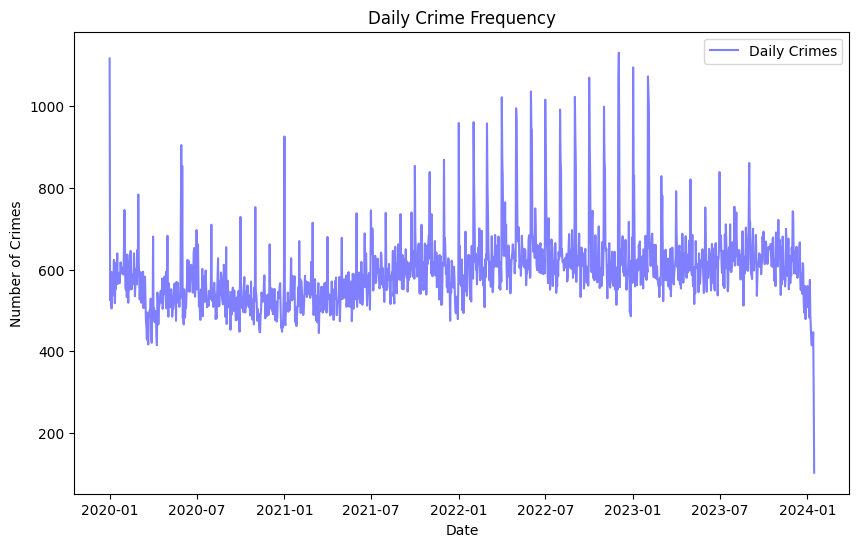

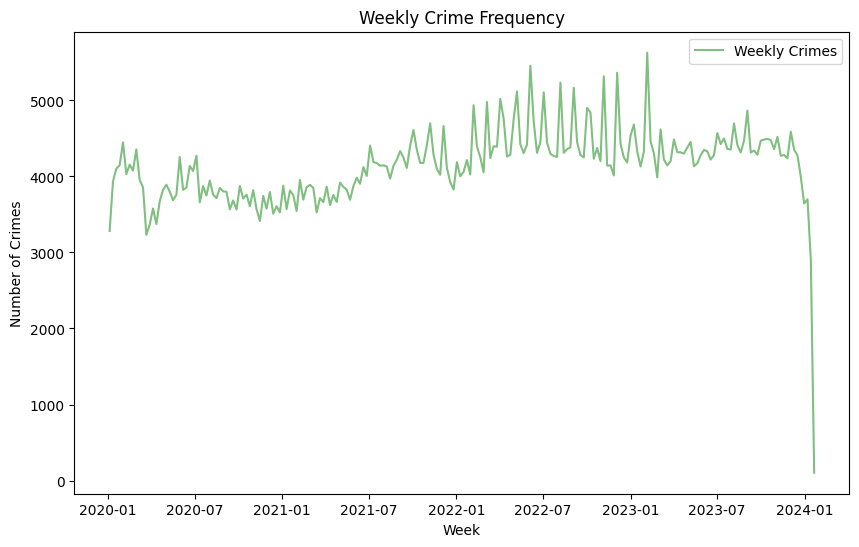

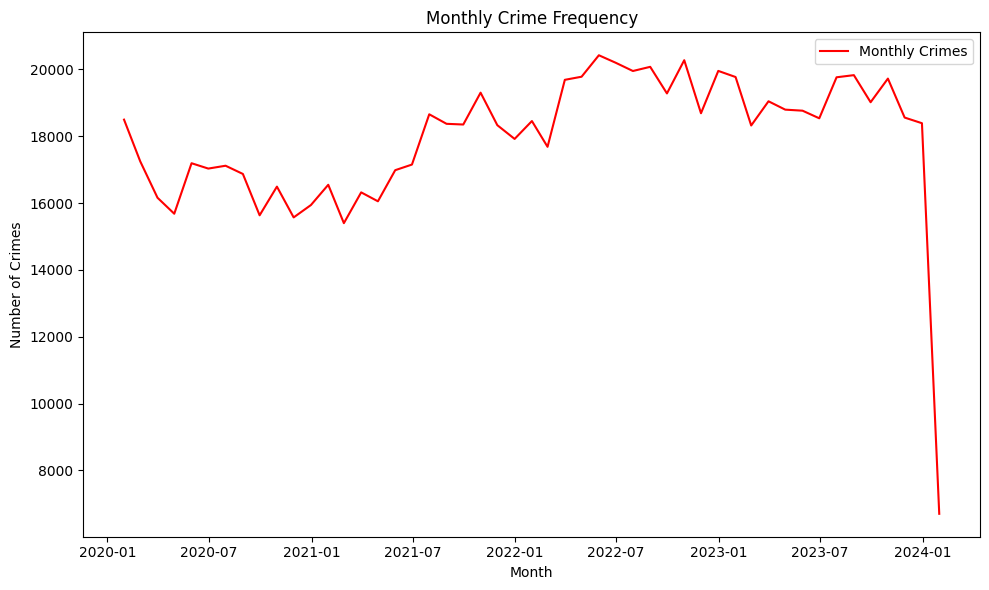

In [14]:
# If DATE OCC is not a column but is the index, bring it back as a column
if "DATE OCC" not in df.columns and df.index.name == "DATE OCC":
    df = df.reset_index()

# Also strip whitespace from column names (handles 'DATE OCC ')
df.columns = df.columns.str.strip()

# Now parse safely
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df = df.dropna(subset=["DATE OCC"])

df_ts = df.set_index("DATE OCC").sort_index()

daily_crimes = df_ts.resample("D").size()
weekly_crimes = df_ts.resample("W").size()
monthly_crimes = df_ts.resample("ME").size()


# Plot daily crimes
plt.figure(figsize=(10, 6))
plt.plot(daily_crimes, label='Daily Crimes', color='blue', alpha=0.5)
plt.title('Daily Crime Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.legend()
plt.show()

# Plot weekly crimes
plt.figure(figsize=(10, 6))
plt.plot(weekly_crimes, label='Weekly Crimes', color='green', alpha=0.5)
plt.title('Weekly Crime Frequency')
plt.xlabel('Week')
plt.ylabel('Number of Crimes')
plt.legend()
plt.show()

# Plot monthly crimes
plt.figure(figsize=(10, 6)) #superimpose avrgaes
plt.plot(monthly_crimes, label='Monthly Crimes', color='red')
plt.title('Monthly Crime Frequency')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.legend()
plt.tight_layout()
plt.show()


## 2.2 Most Common Crimes Category 

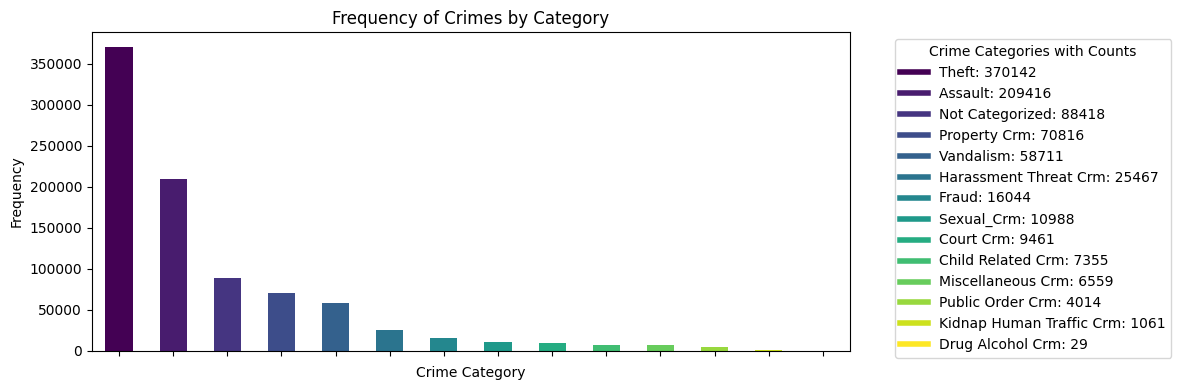

In [15]:
unique_crime_codes = df['Crm Cd'].nunique()
#print("There are", unique_crime_codes, "distinct crime codes in the 'Crm Cd' column.")
crime_code_frequency = df['Crm Cd 1'].value_counts()


# Create a dictionary mapping crime codes to descriptions
crime_code_to_description = dict(zip(df['Crm Cd 1'], df['Crm Cd Desc']))

# Get the most frequent crime codes
all_crime_codes = crime_code_frequency.index

# Define categories as lists of crimes
# Extend the lists of crimes to form groups

theft_related = [
    'VEHICLE - STOLEN',
    'THEFT OF IDENTITY', 
    'THEFT PLAIN - PETTY ($950 & UNDER)', 
    'THEFT PLAIN - ATTEMPT',
    'THEFT FROM MOTOR VEHICLE - ATTEMPT',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)',
    'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)',
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)', 
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)', 
    'SHOPLIFTING - ATTEMPT', 
    'THEFT, PERSON',
    'THEFT FROM PERSON - ATTEMPT',
    'BIKE - STOLEN', 
    'BIKE - ATTEMPTED STOLEN', 
    'VEHICLE - ATTEMPT STOLEN', 
    'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)',
    'THEFT FROM PERSON - ATTEMPT',
    'THEFT, COIN MACHINE - GRAND ($950.01 & OVER)', 
    'THEFT, COIN MACHINE - PETTY ($950 & UNDER)',
    'THEFT, COIN MACHINE - ATTEMPT', 
    'TILL TAP - PETTY ($950 & UNDER)', 
    'TILL TAP - GRAND THEFT ($950.01 & OVER)',
    'BOAT - STOLEN', 
    'BOAT - ATTEMPTED STOLEN',
    'ROBBERY', 
    'ATTEMPTED ROBBERY',
    'PICKPOCKET',
    'PICKPOCKET, ATTEMPT',
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER',
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01',
    'PURSE SNATCHING',
    'PURSE SNATCHING - ATTEMPT',
    'PETTY THEFT - AUTO REPAIR',
    'GRAND THEFT / AUTO REPAIR',
    'DISHONEST EMPLOYEE - GRAND THEFT',
    'DISHONEST EMPLOYEE - PETTY THEFT',
    'DISHONEST EMPLOYEE ATTEMPTED THEFT'
    
]

assault_related = [
    'BATTERY - SIMPLE ASSAULT', 
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 
    'INTIMATE PARTNER - SIMPLE ASSAULT',
    'INTIMATE PARTNER - AGGRAVATED ASSAULT', 
    'BATTERY WITH SEXUAL CONTACT',
    'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER',
    'CRIMINAL HOMICIDE', 
    'MANSLAUGHTER, NEGLIGENT',
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT (ADW)',
    'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER (ADW ON PO)', 
    'BATTERY POLICE (SIMPLE)', 
    'BATTERY ON A FIREFIGHTER',
    'THROWING OBJECT AT MOVING VEHICLE', 
    'BATTERY POLICE (SIMPLE)', 
    'CRIMINAL THREATS - NO WEAPON DISPLAYED',
    'SHOTS FIRED AT INHABITED DWELLING',
    'WEAPONS POSSESSION/BOMBING',
    'LYNCHING',
    'REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)',
    'OTHER ASSAULT'
]

vandalism_related = [
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)',
    'VANDALISM - MISDEMEANOR ($399 OR UNDER)',
    'ARSON', 
    'DISCHARGE FIREARMS/SHOTS FIRED',
    'SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT'
    
]

fraud_related = [
    'FORGERY',
    'FRAUD USE CREDIT CARDS ($950 & UNDER)',
    'FRAUD USE CREDIT CARDS ($950.01 & OVER)',
    'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)',
    'EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)',
    'BUNCO, ATTEMPT',
    'BUNCO, PETTY THEFT',
    'BUNCO, GRAND THEFT',
    'DOCUMENT FORGERY / STOLEN FELONY',
    'COUNTERFEIT',
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER',
    'DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01',
    'UNAUTHORIZED COMPUTER ACCESS',
    'ILLEGAL DUMPING',
    'CONSPIRACY',
    'BRIBERY',
    'FALSE IMPRISONMENT',
    'FALSE POLICE REPORT',
    'CREDIT CARDS, FRAUD USE ($950.01 & OVER)',
    'CREDIT CARDS, FRAUD USE ($950 & UNDER',
    'DOCUMENT WORTHLESS ($200.01 & OVER)',
    'DOCUMENT WORTHLESS ($200 & UNDER)',
    'GRAND THEFT / INSURANCE FRAUD',
    'BIGAMY'
]

sexual_crimes = [
    'RAPE, FORCIBLE',
    'RAPE, ATTEMPTED',
    'SEXUAL PENETRATION W/FOREIGN OBJECT',
    'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ',
    'SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH',
    'LEWD CONDUCT',
    'INDECENT EXPOSURE', 
    'PEEPING TOM',
    'PIMPING',
    'PANDERING',
    'PROWLER',
    'SEX OFFENDER REGISTRANT OUT OF COMPLIANCE',
    'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM',
    'ORAL COPULATION',
    'HUMAN TRAFFICKING - COMMERCIAL SEX ACTS',
    'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)'
]

drug_alcohol_related = [
    'DRUNK ROLL',
    'POSSESSION OF CONTROLLED SUBSTANCE'
]

harassment_threat_related = [
    'CRIMINAL THREATS - NO WEAPON DISPLAYED',
    'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD',
    'THREATENING PHONE CALLS/LETTERS',
    'STALKING',
    'CHILD ANNOYING (17YRS & UNDER)',
    'BRANDISH WEAPON',
    'BOMB SCARE',
    'EXTORTION',
    'DRIVING WITHOUT OWNER CONSENT (DWOC)'
]

property_related = [
    'BURGLARY FROM VEHICLE, ATTEMPTED',
    'BURGLARY, ATTEMPTED',
    'BURGLARY',
    'TRESPASSING',
    'LOITERING',
    'PROWLER',
    'TELEPHONE PROPERTY - DAMAGE'
]

public_order_related = [
    'DISTURBING THE PEACE',
    'FAILURE TO YIELD',
    'BLOCKING DOOR INDUCTION CENTER',
    'FAILURE TO DISPERSE',
    'INCITING A RIOT',
    'RECKLESS DRIVING',
    'FAILURE TO DISPERSE',
    'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
    'RESISTING ARREST'
]
kidnapping_human_trafficking= [
        'HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE',
        'KIDNAPPING',
        'KIDNAPPING - GRAND ATTEMPT'
]
child_related=[
        'CHILD STEALING', 
        'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT',
        'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT',
        'CHILD PORNOGRAPHY',
        'LEWD/LASCIVIOUS ACTS WITH CHILD',
        'DRUGS, TO A MINOR',
        'CHILD ANNOYING (17YRS & UNDER)',
        'DISRUPT SCHOOL',
        'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)', 
        'CHILD NEGLECT (SEE 300 W.I.C.)',
        'CHILD ABANDONMENT',
        'CONTRIBUTING'
]
miscellaneous_crimes=['OTHER MISCELLANEOUS CRIME', 
        'CRUELTY TO ANIMALS'
       ]
court_related=[
        'VIOLATION OF COURT ORDER', 
        'CONTEMPT OF COURT',
        'RESISTING ARREST',
        'VIOLATION OF TEMPORARY RESTRAINING ORDER',
        'VIOLATION OF TEMPORARY ORDER'
]


total_theft_related = len(theft_related)
total_assault_related = len(assault_related)
total_vandalism_related = len(vandalism_related)
total_fraud_related = len(fraud_related)
total_sexual_crimes = len(sexual_crimes)
total_drug_alcohol_related = len(drug_alcohol_related)
total_property_related=len(property_related)
total_public_order_related=len(public_order_related)
total_harassment_threat_related=len(harassment_threat_related)
total_kidnapping_human_trafficking=len(kidnapping_human_trafficking)
total_child_related=len(child_related)
total_court_related=len(court_related)
total_miscellaneous_crimes=len(miscellaneous_crimes)

# Calculate the total number of unique crimes
total_unique_crimes = (
    total_theft_related + total_assault_related + total_vandalism_related +
    total_fraud_related + total_sexual_crimes + total_drug_alcohol_related 
    + total_property_related + total_public_order_related + total_harassment_threat_related + total_kidnapping_human_trafficking + total_child_related + total_court_related
)
#print(total_unique_crimes)

# Create a new column in the DataFrame to assign each crime a category
def assign_category(crime):
    if crime in theft_related:
        return 'Theft'
    elif crime in assault_related:
        return 'Assault'
    elif crime in vandalism_related:
        return 'Vandalism'
    elif crime in fraud_related:
        return 'Fraud'
    elif crime in sexual_crimes:
        return 'Sexual_Crm'
    elif crime in drug_alcohol_related:
        return 'Drug Alcohol Crm'
    elif crime in property_related:
        return 'Property Crm'
    elif crime in public_order_related:
        return 'Public Order Crm'
    elif crime in harassment_threat_related:
        return 'Harassment Threat Crm'
    elif crime in kidnapping_human_trafficking:
        return 'Kidnap Human Traffic Crm'
    elif crime in miscellaneous_crimes:
        return 'Miscellaneous Crm'
    elif crime in child_related:
        return 'Child Related Crm'
    elif crime in court_related:
        return 'Court Crm'
    else:
        return 'Not Categorized'

df['Category'] = df['Crm Cd Desc'].apply(assign_category)


category_counts = df['Category'].value_counts()
#print(category_counts)



# Define a color for each bar
colors = plt.cm.viridis(np.linspace(0, 1, len(category_counts)))
# Creating a list of legend entries with the correct label and color pair
legend_entries = [plt.Line2D([0], [0], color=color, lw=4, label=f'{category}: {count}') 
                  for (category, count), color in zip(category_counts.items(), colors)]

# Plotting with unique colors for each bar
fig, ax = plt.subplots(figsize=(12, 4))
category_counts.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Frequency of Crimes by Category')
ax.set_xlabel('Crime Category')
ax.set_ylabel('Frequency')
# Remove x-axis labels
ax.set_xticklabels([])
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels for better visibility

# Add the custom legend entries to the plot
ax.legend(handles=legend_entries, title='Crime Categories with Counts', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

## 2.3 Trend Analysis over Time 
This is an interactive plot. You can select each category from drop down to see the crime frequency over the years.

In [16]:
import sys
!"{sys.executable}" -m pip install -U nbformat ipykernel
df.columns = df.columns.str.strip()

df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df = df.dropna(subset=["DATE OCC"])

monthly_crime_data = (
    df.groupby("Category")
      .resample("ME", on="DATE OCC")
      .size()
      .unstack(0)
      .fillna(0)
)

if isinstance(monthly_crime_data.index[0], tuple):
    monthly_crime_data.index = pd.to_datetime(monthly_crime_data.index.map(lambda x: f"{x[0]}-{x[1]:02d}"))

# Create a figure
fig = go.Figure()

# List of all categories
categories = monthly_crime_data.columns

# Adding traces for each category
for category in categories:
    fig.add_trace(
        go.Scatter(
            x=monthly_crime_data.index, 
            y=monthly_crime_data[category],
            name=category,
            visible=False  # Start with all traces hidden
        )
    )

# Make the first trace visible
fig.data[0].visible = True

# Create a dropdown menu to select the crime category
buttons = []
for i, category in enumerate(categories):
    buttons.append(dict(
        label=category,
        method="update",
        args=[{"visible": [j == i for j in range(len(categories))]},
              {"title": f"Monthly Crime Trends for {category}"}]
    ))

# Adding dropdowns to the layout
fig.update_layout(
    title="Select a Crime Category to Display",
    showlegend=True,
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "showactive": True,
        "x": 0.5,  # X position of the dropdown (0.5 is the middle of the plot)
        "y": 1.15,  # Y position of the dropdown (1.15 is above the top edge of the plot)
        "xanchor": "center",  # Anchor the x position at the center of the dropdown
        "yanchor": "top"  # Anchor the y position at the top of the dropdown
    }]
    
)
# Axis labels and layout adjustments
fig.update_xaxes(
    title_text='Month',
    tickformat='%b\n%Y',  # Format x-axis ticks to show abbreviated month and full year
    ticklabelmode="period")  # Ensure labels show only one label per period (month)

fig.update_yaxes(title_text='Number of Crimes')

fig.show()


# 2.4 Compare Each Month of all years with respect to Categories 

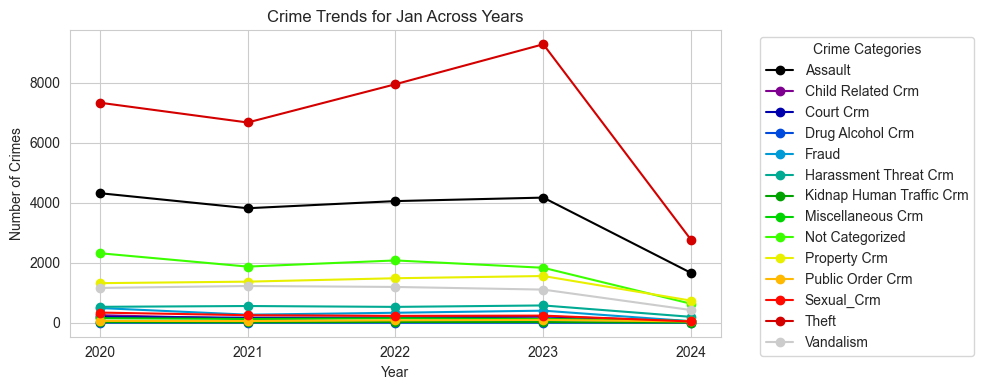

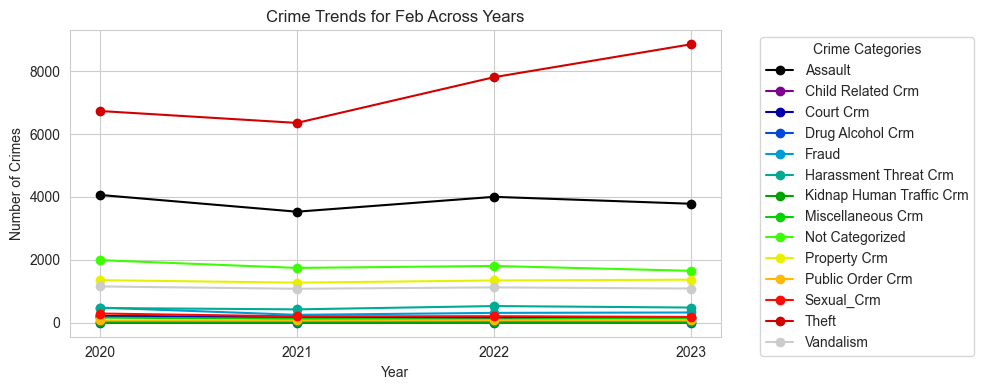

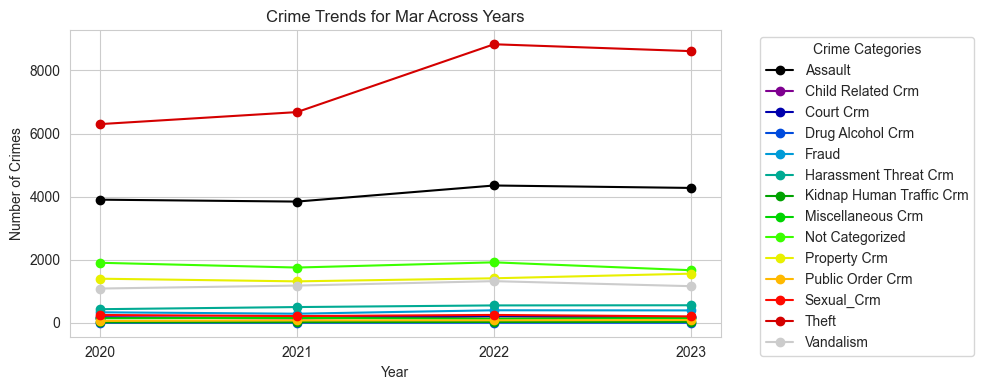

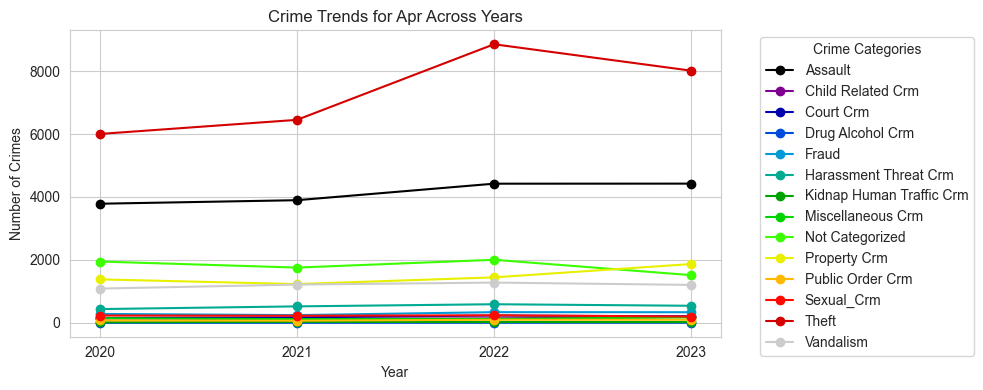

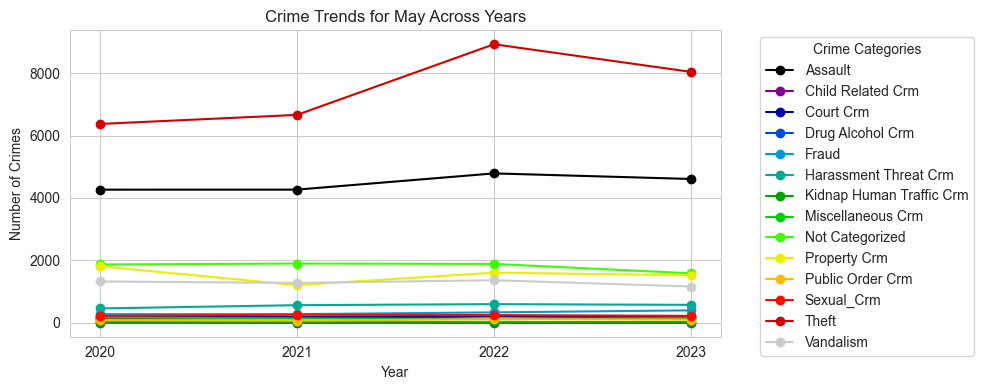

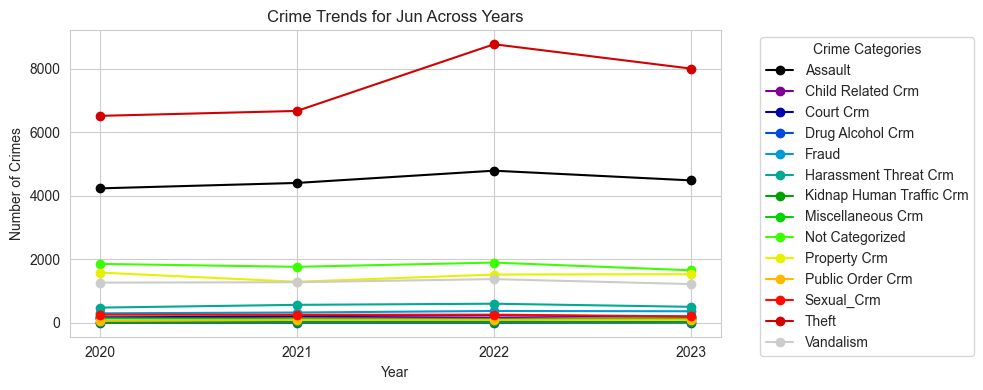

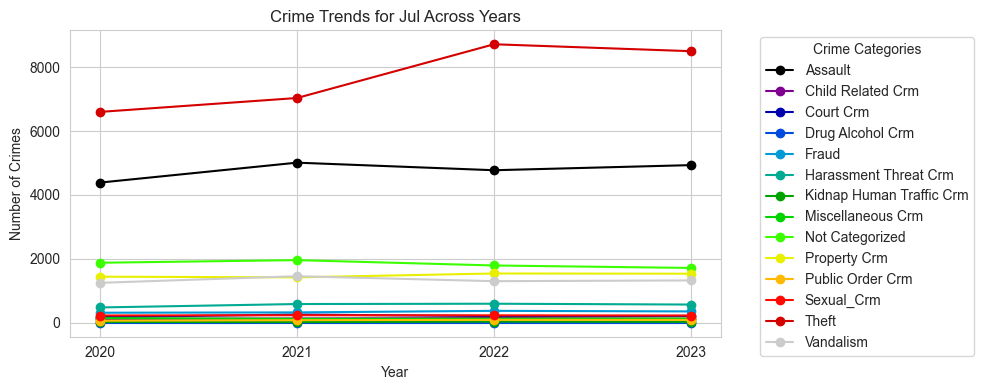

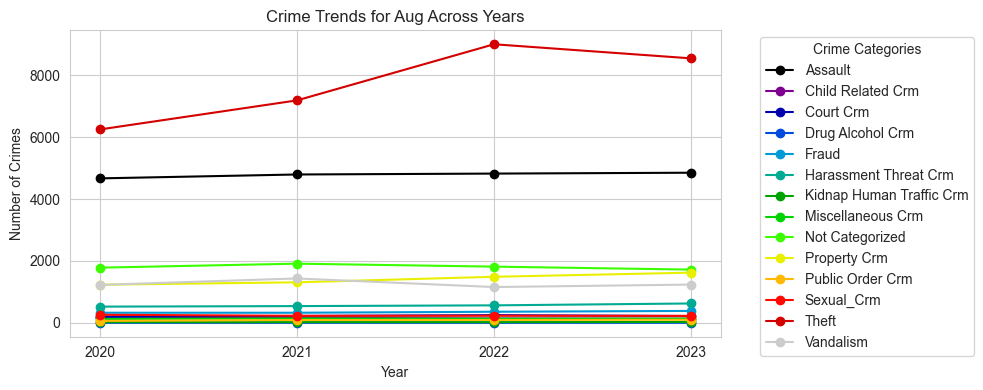

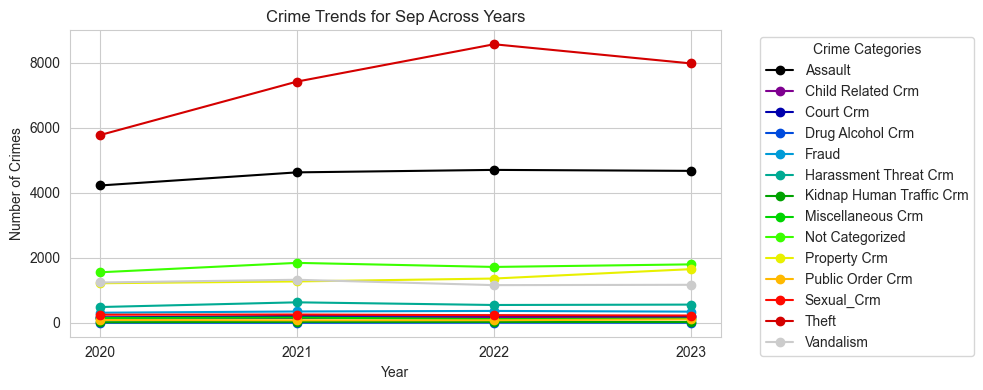

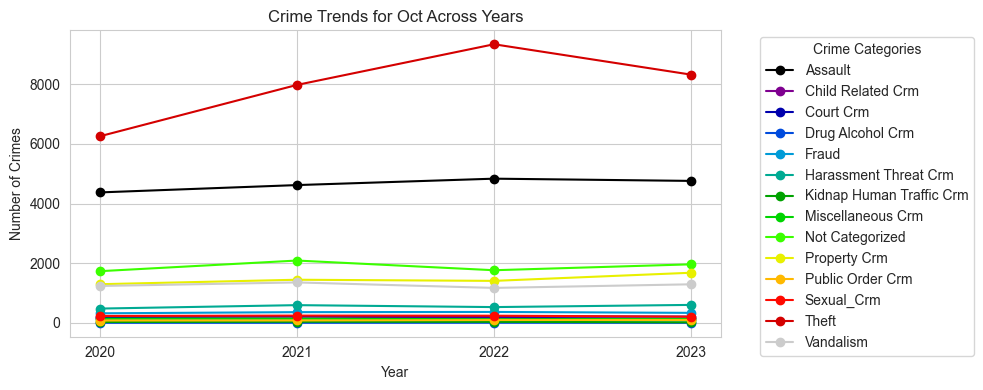

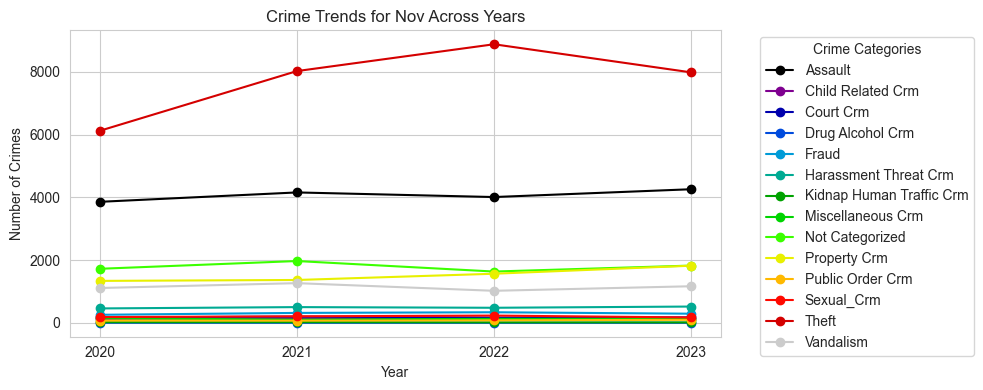

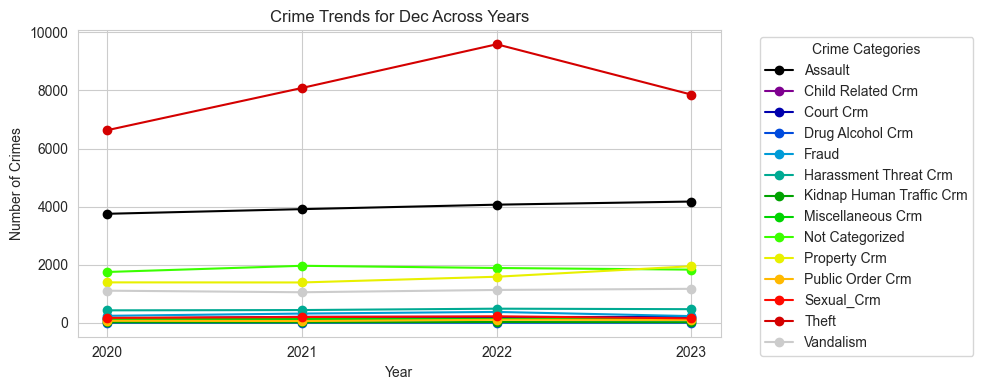

In [30]:

# Group by 'Category', 'Year', and 'Month', and count occurrences
monthly_crime_data = df.groupby(['Category', 'Year', 'Month']).size().unstack(level=0).fillna(0)

# Define a color map (colormap) that can generate enough unique colors
num_categories = len(monthly_crime_data.columns)
colors = plt.cm.nipy_spectral(np.linspace(0, 1, num_categories))

# Create a dictionary to map each category to a unique color
category_colors = {category: color for category, color in zip(monthly_crime_data.columns, colors)}

# Plot data for each month across different years
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for i in range(1, 13):  # From January (1) to December (12)
    plt.figure(figsize=(10, 4))
    for category in monthly_crime_data.columns:
        # Select the data for the specific month across all years
        data_to_plot = monthly_crime_data.xs(i, level='Month')[category]
        if not data_to_plot.empty:
            plt.plot(data_to_plot.index, data_to_plot.values, marker='o', linestyle='-', label=category,
                     color=category_colors[category])  # Use the color mapped to the category
    
    plt.title(f'Crime Trends for {months[i-1]} Across Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.xticks(data_to_plot.index)  # Ensure all years are displayed
    plt.legend(title='Crime Categories', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 2.5 Time of Crime Occuring 

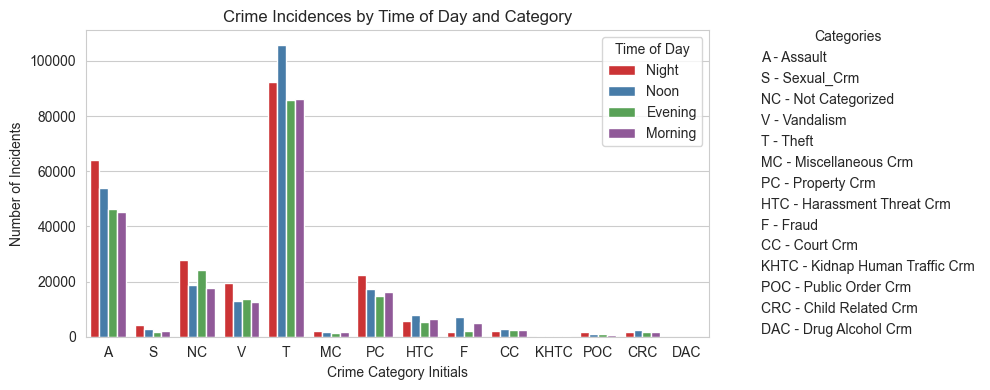

In [18]:
# Function to convert time in HHMM format to categorical periods
def categorize_time(time):
    # Convert time to a four-digit string, zero-padded on the left
    time_str = str(time).zfill(4)
    # Extract hours and minutes
    hours = int(time_str[0:2])
    minutes = int(time_str[2:4])
    
    if 5 <= hours < 12:
        return 'Morning'
    elif 12 <= hours < 17:
        return 'Noon'
    elif 17 <= hours < 21:
        return 'Evening'
    else:
        return 'Night'

# Apply the categorization function to the 'TIME OCC' column
df['Time Category'] = df['TIME OCC'].apply(categorize_time)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

category_initials = {category: ''.join(word[0] for word in category.split()) for category in df['Category'].unique()}
#print(category_initials)  # Print to verify the initials

df['Category Initials'] = df['Category'].map(category_initials)

# Create a count plot
plt.figure(figsize=(10, 4))
ax = sns.countplot(x='Category Initials', hue='Time Category', data=df, palette='Set1')
plt.title('Crime Incidences by Time of Day and Category')
plt.xlabel('Crime Category Initials')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=0)

# Handling legends for Time Category
handles, labels = ax.get_legend_handles_labels()
time_legend = ax.legend(handles, labels, title='Time of Day', loc='upper right')

# Custom legend for category names using initials and full names
legend_elements = [Patch(facecolor='none', edgecolor='none', label=f"{init} - {cat}") 
                   for init, cat in zip(df['Category Initials'].unique(), df['Category'].unique())]
category_legend = ax.legend(handles=legend_elements, title="Categories", loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# Add back the time category legend
ax.add_artist(time_legend)

plt.tight_layout()
plt.show()

## 2.6 Geographic Distribution

In [ ]:
# Ensure LAT and LON are numeric
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')

# Drop rows where coordinates are missing
df = df.dropna(subset=['LAT', 'LON'])
# Create a map centered around an average location
map_center = [df['LAT'].mean(), df['LON'].mean()]
crime_map = folium.Map(location=map_center, zoom_start=11)

# Create a heatmap
heat_data = [[row['LAT'], row['LON']] for index, row in df.iterrows()]
HeatMap(heat_data, radius=15, blur=10, max_zoom=1).add_to(crime_map)

HeatMap(heat_data).add_to(crime_map)

# Save to HTML and display
crime_map.save('LA_Crime_Heatmap.html')
crime_map

## 2.7 Customize for Crime Categories
The heatmaps for each crime category will be created and saved in your computer. You will see html files in your folder. 

In [21]:
#for category in df['Category'].unique():
map_center = [df['LAT'].mean(), df['LON'].mean()]
crime_map = folium.Map(location=map_center, zoom_start=11)
    
    # Filtering data for the category
cat_data = df[df['Category'] == category]
heat_data = [[row['LAT'], row['LON']] for index, row in cat_data.iterrows()]
    
    # Create a heatmap for the category
HeatMap(heat_data).add_to(crime_map)
crime_map.save(f'LA_Crime_Heatmap_{category}.html')

## 2.8 Frequency of Crime Categories with respect to Area
This is an interactive graph made by Plotly. If you hover over it you will be able to see more details. If you click the categories in legend you can select individual category from the list and see it.

In [22]:
# Group the data by 'AREA NAME' and 'Category' and count the occurrences
area_category_counts = df.groupby(['AREA NAME', 'Category']).size().unstack(fill_value=0)

# Convert the pandas DataFrame from wide to long format, which is suitable for Plotly
long_df = area_category_counts.reset_index().melt(id_vars='AREA NAME', var_name='Category', value_name='Frequency')

# Create an interactive bar chart
fig = px.bar(long_df, x='AREA NAME', y='Frequency', color='Category', title='Frequency of Crime Categories by Area',
             hover_data=['Category', 'Frequency'], labels={'AREA NAME': 'Area Name', 'Frequency': 'Frequency of Crimes'},
             color_discrete_sequence=px.colors.qualitative.Alphabet)  # Using a vibrant, distinct color sequence

# Improve the layout
fig.update_layout(xaxis_title='Area Name',
                  yaxis_title='Frequency of Crimes',
                  legend_title='Crime Categories',
                  xaxis_tickangle=-45,  # Rotate labels for better visibility
                  legend=dict(y=1, x=1.1, title_font=dict(size=15), font=dict(size=12)))  # Adjust legend positioning

# Show the plot
fig.show()


Dominance of Certain Crime Categories: 
The chart shows that some crime categories like 'Assault', 'Theft', and possibly 'Drug Alcohol Crm' dominate in all areas. These categories have the highest frequencies across most of the areas shown.
Variability Across Areas: 
Some areas have higher overall crime frequencies than others. For instance, 'Central', '77th Street', 'Hollywood', 'Pacific' 'Southwest', and 'West LA' exhibit notably higher frequencies of crimes compared to other areas.

## 2.9 Demographical Distribution

C:\Users\rasman khurshid\AppData\Local\Temp\ipykernel_13640\1906301194.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




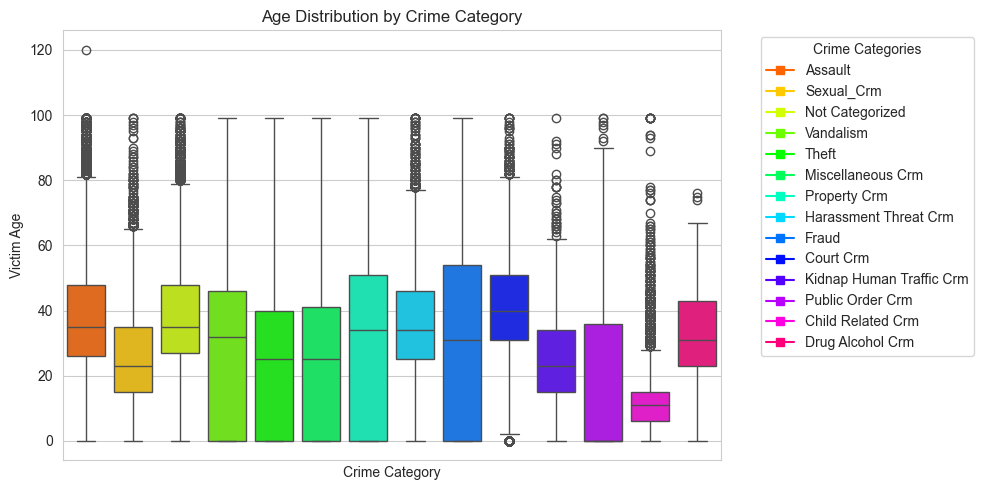

In [23]:
# Creating a color palette
palette = sns.color_palette("hsv", n_colors=len(df['Category'].unique()))

# Map categories to colors
category_colors = {category: color for category, color in zip(df['Category'].unique(), palette)}

# Plot age distribution for each crime category
plt.figure(figsize=(10, 5))
box_plot = sns.boxplot(x='Category', y='Vict Age', data=df, palette=category_colors)
plt.title('Age Distribution by Crime Category')
plt.xlabel('Crime Category')
plt.ylabel('Victim Age')

# Hide x-ticks and add legend
plt.xticks([])
plt.legend(handles=[plt.Line2D([0], [0], color=category_colors[cat], label=cat, marker='s') for cat in df['Category'].unique()],
           title='Crime Categories', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Adjust layout
plt.show()

### 2.10 Visualize Gender Distribution by Crime Category

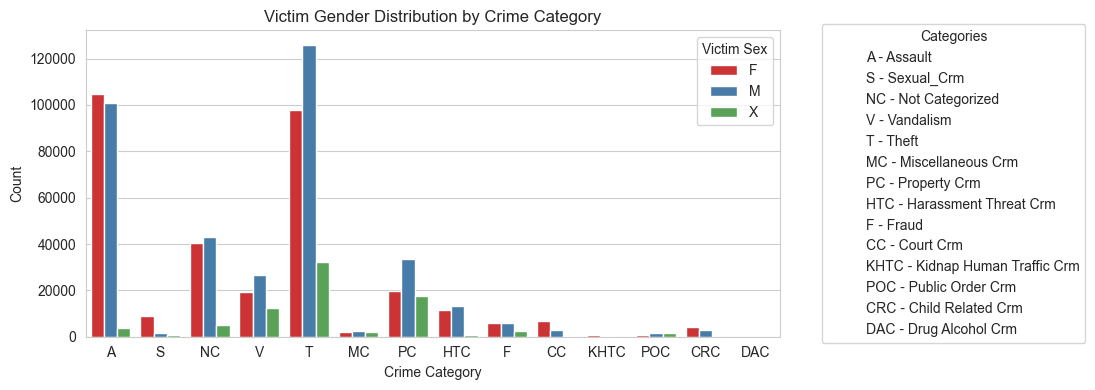

In [24]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(x='Category Initials', hue='Vict Sex', data=df, palette='Set1')

# Setting x-axis labels and chart title
plt.title('Victim Gender Distribution by Crime Category')
plt.xlabel('Crime Category')
plt.ylabel('Count')
plt.tight_layout()  # Adjust layout for better display

handles, labels = ax.get_legend_handles_labels()
sex_legend = ax.legend(handles, labels, title="Victim Sex")


# Add this new legend to the plot. Adjust position as necessary.
category_legend = ax.legend(handles=legend_elements, title="Categories", bbox_to_anchor=(1.05, 0.5), loc='center left')

# Add back the first legend for 'Victim Sex'
ax.add_artist(sex_legend)
plt.show()


### 2.11 Crime Status: What percentage of crimes are solved vs. under investigation?

In [25]:
# Count occurrences of each status
status_counts = df['Status'].value_counts()

# Calculate total number of cases
total_cases = df['Status'].count()

# Calculate percentages
status_percentages = (status_counts / total_cases) * 100

# Combine counts and percentages with descriptions
status_info = pd.concat([status_counts, status_percentages], axis=1)
status_info.columns = ['Counts', 'Percentages']

unique_statuses = df[['Status', 'Status Desc']].drop_duplicates().set_index('Status')
status_info = status_info.join(unique_statuses)

# Display combined info
print("\nStatus Information with Descriptions:")
status_info


Status Information with Descriptions:


,Counts,Percentages,Status Desc
Status,,,
IC,703632,80.096439,Invest Cont
AO,94295,10.733869,Adult Other
AA,76172,8.670876,Adult Arrest
JA,2851,0.324537,Juv Arrest
JO,1527,0.173823,Juv Other
CC,4,0.000455,UNK


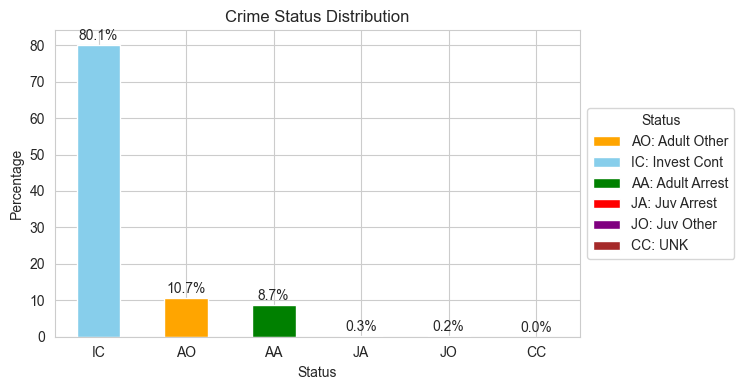

In [26]:
colors = ['orange', 'skyblue', 'green', 'red', 'purple', 'brown']

color_map = dict(zip(unique_statuses.index, colors))

#plot the percentages
fig, ax = plt.subplots(figsize=(6, 4))
status_percentages.plot(
    kind='bar',
    color=[color_map.get(x) for x in status_percentages.index],
    legend=False
)
plt.title('Crime Status Distribution')
plt.xlabel('Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.tight_layout()

# Create custom legend labels with status codes and descriptions
legend_labels = [f'{code}: {desc}' for code, desc in zip(unique_statuses.index, unique_statuses['Status Desc'])]

# Create custom legend handles (colored patches)
legend_handles = [Patch(facecolor=color_map.get(code), label=label) for code, label in zip(unique_statuses.index, legend_labels)]

# Place the legend on the plot
ax.legend(handles=legend_handles, title='Status', loc='center left', bbox_to_anchor=(1, 0.5))

# Add text annotations for percentages on top of each bar
for i, v in enumerate(status_percentages):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')

plt.show()


# Section 3: Related Crime Prediction

## 3.1 Objective
The goal is to understand how these crimes are related to one another and to identify patterns or rules indicating which crimes are likely to occur together.

In [33]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# df has columns 'DR_NO', 'Crm Cd', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'
# Replace 'No Additional Crime' with NaN
df = df.replace('No Additional Crime', pd.NA)

# Combine the crime codes into a list for each record
df['Crimes'] = df[['Crm Cd', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']].values.tolist()

# Drop rows where all crime codes are NaN
df = df.dropna(subset=['Crimes'], how='all')

# Convert the crimes into a transaction list format
transactions = df['Crimes'].apply(lambda x: [crime for crime in x if pd.notna(crime)]).tolist()

# Convert the transaction data into a one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

# Display the one-hot encoded DataFrame
df_onehot.head()

# Apply the Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(df_onehot, min_support=0.01, use_colnames=True)

# Display the frequent itemsets
print(frequent_itemsets)

# Generate the association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Display the association rules
print(rules)



     support                        itemsets
0   0.999929                frozenset({0.0})
1   0.034201              frozenset({210.0})
2   0.057255              frozenset({230.0})
3   0.013692              frozenset({236.0})
4   0.060936              frozenset({310.0})
5   0.061827              frozenset({330.0})
6   0.035872              frozenset({331.0})
7   0.033101              frozenset({341.0})
8   0.062260              frozenset({354.0})
9   0.038543              frozenset({420.0})
10  0.051085              frozenset({440.0})
11  0.024965              frozenset({442.0})
12  0.107620              frozenset({510.0})
13  0.080405              frozenset({624.0})
14  0.051281              frozenset({626.0})
15  0.061462              frozenset({740.0})
16  0.026645              frozenset({745.0})
17  0.015955              frozenset({761.0})
18  0.015001              frozenset({888.0})
19  0.012762              frozenset({901.0})
20  0.024672              frozenset({930.0})
21  0.0604

### 3.2 Interpretation of Results
Here are the association rules we have:

Rule 1: (998.0) -> (230.0)

Support: 0.012667
Confidence: 0.208987
Lift: 3.650661
Leverage: 0.009197
Conviction: 1.191831
Zhang's Metric: 0.772924
Rule 2: (230.0) -> (998.0)

Support: 0.012667
Confidence: 0.221268
Lift: 3.650661
Leverage: 0.009197
Conviction: 1.206307
Zhang's Metric: 0.770166
#### Understanding the Metrics: 
Support: This represents the proportion of cases where the rule holds true (i.e., both crimes occurred together). A support of 0.012667 means that 1.27% of all transactions in the dataset contain both crime codes 998.0 and 230.0.

Confidence: This represents how often the consequent (crime 230.0) occurs in transactions that contain the antecedent (crime 998.0). For rule 1, a confidence of 0.208987 means that in about 20.9% of cases where crime 998.0 occurs, crime 230.0 also occurs.

Lift: This measures how much more likely the consequent (crime 230.0) is to occur given the antecedent (crime 998.0) compared to its general occurrence in the dataset. A lift greater than 1 indicates a positive association. Here, a lift of 3.650661 suggests that crime 230.0 is 3.65 times more likely to occur with crime 998.0 than by itself.

Leverage: This measures the difference in the probability of the antecedent and consequent appearing together in the dataset compared to what would be expected if they were independent. A positive leverage value indicates a positive association.

Conviction: This metric measures the reliability of the rule. A conviction value greater than 1 indicates that the rule has predictive power. Here, both rules have a conviction value slightly above 1.

Zhang's Metric: This is another measure of rule strength, with higher values indicating stronger rules.

Implications: 
The rules suggest that there is a notable association between crime codes 998.0 and 230.0. Crime 230 is ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT and Crime 998 is VANDALISM - MISDEAMEANOR ($399 OR UNDER). When crime 998.0 occurs, crime 230.0 is also likely to occur, and vice versa. These insights can help in predicting and understanding the patterns of crimes that tend to co-occur.

#### 3.3 Network Graph of Association Rules 

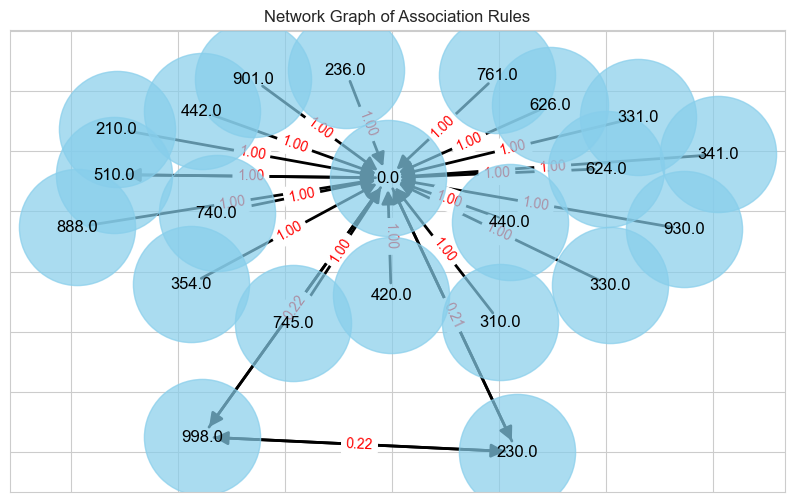

In [34]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges to the graph
for _, row in rules.iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    G.add_edge(antecedent, consequent, weight=row['confidence'])

# Define the layout for the graph
pos = nx.spring_layout(G, k=1)

# Draw the nodes
plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G, pos, node_size=7000, node_color='skyblue', alpha=0.7)

# Draw the edges
edges = nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='black', width=2)

# Draw the labels
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')

# Draw edge labels (confidence)
edge_labels = { (list(row['antecedents'])[0], list(row['consequents'])[0]): f"{row['confidence']:.2f}" for _, row in rules.iterrows() }
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title('Network Graph of Association Rules')
plt.show()



In [35]:
# Extract unique crime codes and their descriptions
crime_descriptions = df[['Crm Cd 2', 'Crm Cd Desc']].drop_duplicates()

# Look up descriptions for the specific crime codes
desc_998 = crime_descriptions[crime_descriptions['Crm Cd 2'] == 998.0]['Crm Cd Desc'].values[0]
#desc_230 = crime_descriptions[crime_descriptions['Crm Cd'] == 230.0]['Crm Cd Desc'].values[0]

# Print the descriptions
print(f"Description for crime code 998.0: {desc_998}")
#print(f"Description for crime code 230.0: {desc_230}")

Description for crime code 998.0: VANDALISM - MISDEAMEANOR ($399 OR UNDER)


Predict if an aggravated assault (crime code 230.0) will occur given features such as location, time, and history of vandalism (crime code 998.0).

## The End